In [93]:
import pandas as pd
import numpy as np

In [94]:
df = pd.read_csv('train-metadata.csv', low_memory = False)
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [95]:
print("Number of Images: ", len(df))
print("Number of Malignant: ", len(df[df['target'] == 1]))
print("Number of Benign: ", len(df[df['target'] == 0]))

Number of Images:  401059
Number of Malignant:  393
Number of Benign:  400666


In [96]:
print("Number of Patients: ", len(np.unique(df['patient_id'])))

Number of Patients:  1042


In [97]:
duplicate = df[df.duplicated('patient_id', keep = False)]
print("Total Number of Duplicates: ", len(duplicate))
print("Number of Patients with Duplicates: ", len(np.unique(duplicate['patient_id'])))
print("Number of Patients with No Duplicates: ", 1042 - 1037)

Total Number of Duplicates:  401054
Number of Patients with Duplicates:  1037
Number of Patients with No Duplicates:  5


In [128]:
# duplicate counts for the 1037 patient_id
duplicate_counts = duplicate.groupby('patient_id').size().sort_values(ascending = False)
duplicate.loc[:, 'count'] = duplicate['patient_id'].map(duplicate_counts)

duplicate_counts

patient_id
IP_1117889    9184
IP_5714646    6267
IP_3921915    5568
IP_7797815    4454
IP_9577633    3583
              ... 
IP_3772472       3
IP_6066606       3
IP_9022855       2
IP_1510720       2
IP_9979014       2
Length: 1037, dtype: int64

In [99]:
duplicate_counts.describe()

count    1037.000000
mean      386.744455
std       540.910845
min         2.000000
25%       118.000000
50%       242.000000
75%       481.000000
max      9184.000000
dtype: float64

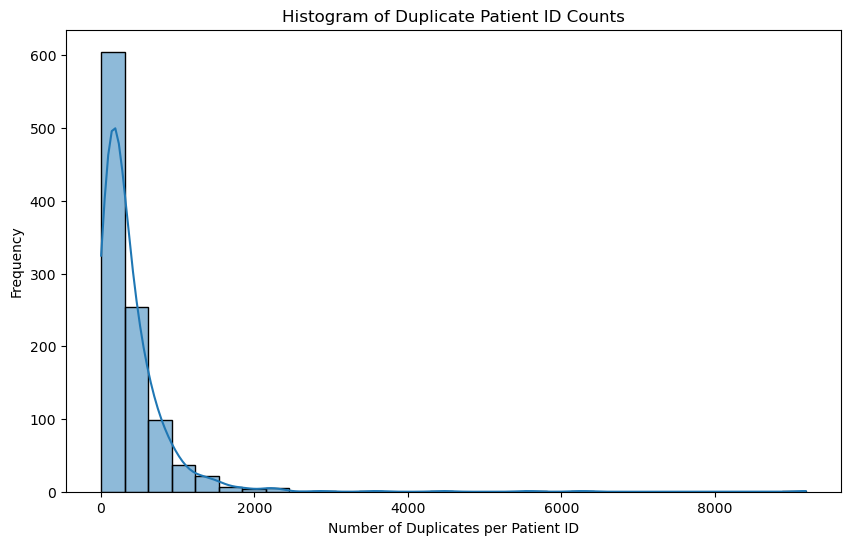

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(duplicate_counts, bins=30, kde=True)

plt.xlabel('Number of Duplicates per Patient ID')
plt.ylabel('Frequency')
plt.title('Histogram of Duplicate Patient ID Counts')

plt.show()

In [101]:
# compute number of patients that only have one photo
nonDuplicates = np.setdiff1d(np.unique(df['patient_id']), np.unique(duplicate['patient_id'])).tolist()
nonDuplicates

['IP_1216329', 'IP_1487179', 'IP_4004571', 'IP_5792391', 'IP_7696347']

In [102]:
# patients with no duplicates
df[df['patient_id'].isin(nonDuplicates)]

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
26508,ISIC_0723418,0,IP_5792391,60.0,male,anterior torso,5.62,TBP tile: close-up,3D: white,17.463460,...,IL_3707392,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.986760
187172,ISIC_4714490,0,IP_1216329,5.0,female,anterior torso,7.94,TBP tile: close-up,3D: white,13.220492,...,IL_4040156,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.564064
340157,ISIC_8500805,0,IP_4004571,40.0,female,upper extremity,3.08,TBP tile: close-up,3D: white,15.736467,...,IL_9028163,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.969172
371762,ISIC_9273542,0,IP_1487179,30.0,female,head/neck,3.70,TBP tile: close-up,3D: XP,22.319834,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000
379199,ISIC_9454701,1,IP_7696347,70.0,male,anterior torso,6.44,TBP tile: close-up,3D: XP,22.397220,...,IL_5305785,Malignant::Malignant melanocytic proliferation...,Malignant,Malignant melanocytic proliferations (Melanoma),Melanoma in situ,"Melanoma in situ, Superficial spreading",NaN,NaN,NaN,100.000000


In [103]:
# target value based on 1037 patient_id
target_vals = duplicate.groupby('patient_id')['target'].sum()

# separate based on target value
# check if any photos submitted by a patient is malignant (patients often submit multiple photos and not all of them are malignant)
malignant_duplicates = target_vals[target_vals >= 1].index.tolist() # at least one photo is malignant if sum of target column for a patient is >= 1
benign_duplicates = target_vals[target_vals == 0].index.tolist()

print("Number of Malignant Duplicate Patients: ", len(malignant_duplicates))
print("Number of Benign Duplicate Patients: ", len(benign_duplicates))

Number of Malignant Duplicate Patients:  258
Number of Benign Duplicate Patients:  779


In [104]:
# malignant duplicate patient ids
duplicate_counts[duplicate_counts.index.isin(malignant_duplicates)]

patient_id
IP_5714646    6267
IP_3921915    5568
IP_7797815    4454
IP_5539318    2859
IP_5143034    2283
              ... 
IP_9781727      54
IP_5471913      50
IP_3987348      46
IP_0273153      46
IP_3905195       8
Length: 258, dtype: int64

In [105]:
# benign duplicate patient ids
duplicate_counts[duplicate_counts.index.isin(benign_duplicates)]

patient_id
IP_1117889    9184
IP_9577633    3583
IP_9853536    2327
IP_1127121    2183
IP_3785831    1852
              ... 
IP_3772472       3
IP_6066606       3
IP_9022855       2
IP_1510720       2
IP_9979014       2
Length: 779, dtype: int64

In [106]:
print("Number of Duplicate Patients with Only One Malignant Photo: ", len(target_vals[target_vals == 1].index.tolist()))

Number of Duplicate Patients with Only One Malignant Photo:  192


In [107]:
# patients with multiple malignant photos
target_vals[target_vals > 1].index

Index(['IP_0277335', 'IP_0321326', 'IP_0669361', 'IP_0889220', 'IP_1045174',
       'IP_1249536', 'IP_1715157', 'IP_1885773', 'IP_1907604', 'IP_1959239',
       'IP_2224950', 'IP_2331257', 'IP_2456971', 'IP_2491677', 'IP_2608498',
       'IP_2732171', 'IP_3026867', 'IP_3056186', 'IP_3144881', 'IP_3154471',
       'IP_3220951', 'IP_3537591', 'IP_3619408', 'IP_3905195', 'IP_3927284',
       'IP_4106376', 'IP_4177511', 'IP_4215006', 'IP_4540594', 'IP_4549819',
       'IP_4717387', 'IP_4849578', 'IP_4890448', 'IP_4934005', 'IP_5202701',
       'IP_5799983', 'IP_6032376', 'IP_6321403', 'IP_6391213', 'IP_6423094',
       'IP_6474130', 'IP_6723298', 'IP_6774617', 'IP_6856511', 'IP_7249064',
       'IP_7411721', 'IP_7695871', 'IP_7746572', 'IP_7797815', 'IP_7977194',
       'IP_8078890', 'IP_8313778', 'IP_8567950', 'IP_8683966', 'IP_8781267',
       'IP_8877928', 'IP_8977835', 'IP_9057861', 'IP_9103159', 'IP_9181133',
       'IP_9211554', 'IP_9324599', 'IP_9453251', 'IP_9496166', 'IP_9588095',

In [108]:
print("Total Number of Malignant Patients (at least one photo submitted has target == 1) for Entire Data: 259")
print("Total Number of Benign Patients (all photos submitted has target == 0) for Entire Data: 783")

Total Number of Malignant Patients (at least one photo submitted has target == 1) for Entire Data: 259
Total Number of Benign Patients (all photos submitted has target == 0) for Entire Data: 783


In [109]:
sites = ['anterior torso', 'head/neck', 'lower extremity',
       'posterior torso', 'upper extremity']
def malignant_sites(patient_id):
    # compute proportion of photos that are malignant for each patient 

    patient = duplicate[duplicate['patient_id'] == patient_id]
    
    for site in sites:
        malignant_count = patient[(patient['anatom_site_general'] == site) & (patient['target'] == 1)].shape[0]
        proportion = malignant_count / len(patient)
        print(f"Site: {site}, Malignant Proportion: {proportion:.4f}")

malignant_sites('IP_3905195')

Site: anterior torso, Malignant Proportion: 0.0000
Site: head/neck, Malignant Proportion: 0.3750
Site: lower extremity, Malignant Proportion: 0.0000
Site: posterior torso, Malignant Proportion: 0.0000
Site: upper extremity, Malignant Proportion: 0.3750


For patient IP_3905195, 70% of the photos they submitted are malignant, with 37.5% of the images located on the head/neck and 37.5% on the upper extremity.